# Sentiment Analysis using ChatGPT 5

In [1]:
import openai
from openai import OpenAI
import json
import os
from dotenv import load_dotenv

# define the environment path. it is at the parent folder
env_path ="../.env"

load_dotenv(dotenv_path=env_path, override=True)

api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI()

MODEL = "gpt-5-chat-latest"

def classify_sentiment(review_text: str) -> dict:
    system = {
        "role": "system",
        "content": (
            "You are a precise sentiment classifier. "
            "Return ONLY valid JSON with keys: label, confidence, rationale. "
            "label ∈ {Positive, Negative, Neutral}. "
            "confidence is a float in [0,1]. rationale ≤ 20 words."
        ),
    }
    user = {
        "role": "user",
        "content": [
            {"type": "text",
             "text": (
                 "Classify the sentiment of the following review. "
                 "Return JSON: {\"label\":\"Positive|Negative|Neutral\",\"confidence\":0-1,\"rationale\":\"...\"}.\n\n"
                 f"Review:\n{review_text}"
             )},
        ],
    }

    resp = client.chat.completions.create(
        model=MODEL,
        messages=[system, user],
        temperature=0,
        response_format={"type": "json_object"},
    )
    return json.loads(resp.choices[0].message.content)

# Example

print(classify_sentiment("Service was fast and the food was amazing! Will come back."))

{'label': 'Positive', 'confidence': 0.98, 'rationale': 'Praises both service and food, expresses intent to return, clearly positive sentiment.'}


# We will apply the above functions to the boston airbnb reviews we used in week 4

In [2]:
import pandas as pd

df=pd.read_csv('data/boston_airbnb_reviews_with_human_labels.csv')

df.head()

,listing_id,id,date,reviewer_id,reviewer_name,human_label,comments
0,1066742,20723614,10/4/2014,4405579,J.L.,Negative,A very unique experience with some unfortunate...
1,3917027,40354718,7/30/2015,33974852,Brandi,Positive,We had a late flight in and had to leave in th...
2,11734812,65464730,3/13/2016,57331722,Saisha,Positive,The apartment was really nice and comfortable....
3,1881298,60264029,1/21/2016,11868914,Jessica,Positive,"Excellent price for a private spot in Boston, ..."
4,3992208,94685296,8/16/2016,47998084,Laura,Negative,Nice neighbourhood. Great location. Very close...


In [4]:
df.shape

(20, 7)

In [5]:
df['ai_output']=df['comments'].apply(classify_sentiment)

In [6]:
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,human_label,comments,ai_output
0,1066742,20723614,10/4/2014,4405579,J.L.,Negative,A very unique experience with some unfortunate...,"{'label': 'Negative', 'confidence': 0.9, 'rati..."
1,3917027,40354718,7/30/2015,33974852,Brandi,Positive,We had a late flight in and had to leave in th...,"{'label': 'Positive', 'confidence': 0.96, 'rat..."
2,11734812,65464730,3/13/2016,57331722,Saisha,Positive,The apartment was really nice and comfortable....,"{'label': 'Positive', 'confidence': 0.98, 'rat..."
3,1881298,60264029,1/21/2016,11868914,Jessica,Positive,"Excellent price for a private spot in Boston, ...","{'label': 'Positive', 'confidence': 0.97, 'rat..."
4,3992208,94685296,8/16/2016,47998084,Laura,Negative,Nice neighbourhood. Great location. Very close...,"{'label': 'Negative', 'confidence': 0.95, 'rat..."


In [7]:
# Extract sentiment from ai_label

import re

df["ai_label"] = df["ai_output"].astype(str).str.extract(r"'label':\s*'([^']*)'")

df.head()

,listing_id,id,date,reviewer_id,reviewer_name,human_label,comments,ai_output,ai_label
0,1066742,20723614,10/4/2014,4405579,J.L.,Negative,A very unique experience with some unfortunate...,"{'label': 'Negative', 'confidence': 0.9, 'rati...",Negative
1,3917027,40354718,7/30/2015,33974852,Brandi,Positive,We had a late flight in and had to leave in th...,"{'label': 'Positive', 'confidence': 0.96, 'rat...",Positive
2,11734812,65464730,3/13/2016,57331722,Saisha,Positive,The apartment was really nice and comfortable....,"{'label': 'Positive', 'confidence': 0.98, 'rat...",Positive
3,1881298,60264029,1/21/2016,11868914,Jessica,Positive,"Excellent price for a private spot in Boston, ...","{'label': 'Positive', 'confidence': 0.97, 'rat...",Positive
4,3992208,94685296,8/16/2016,47998084,Laura,Negative,Nice neighbourhood. Great location. Very close...,"{'label': 'Negative', 'confidence': 0.95, 'rat...",Negative


## Compare AI label with human label

This is a higher agreemnet/accuracy between GPT 5 and my evaluation. We only have one disagreement.
GPT labels one of my nerual reviews as positive.

In [8]:
import os
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# create a function to generate confusion matrix and classification report for sentiment analysis

def classification_evaluation(y_true, y_pred):
    classes = ["Positive", "Neutral", "Negative"]

    # generate Confusion matrix (fixed label order)
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix - Sentiment Analysis")
    plt.show()

    # generate classification report with the SAME labels & names. Use three decimal places
    print(classification_report(y_true, y_pred, labels=classes, target_names=classes, digits=3))

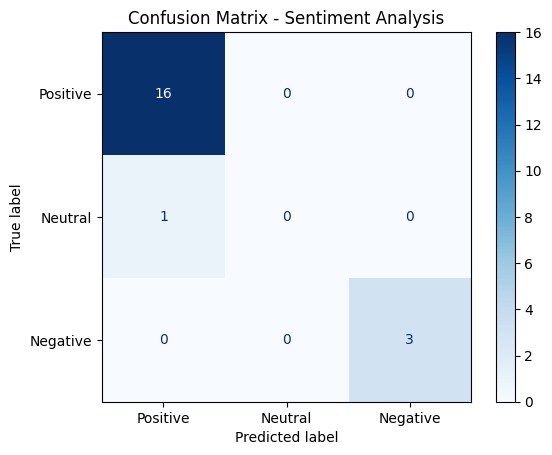

              precision    recall  f1-score   support

    Positive      0.941     1.000     0.970        16
     Neutral      0.000     0.000     0.000         1
    Negative      1.000     1.000     1.000         3

    accuracy                          0.950        20
   macro avg      0.647     0.667     0.657        20
weighted avg      0.903     0.950     0.926        20



/home/sli/.conda/envs/AI500Env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sli/.conda/envs/AI500Env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sli/.conda/envs/AI500Env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [9]:
# Evaluate the model performance

y_true = df['human_label']
y_pred = df['ai_label']
    
classification_evaluation(y_true, y_pred)

# Practice On your Own

Apply GPT-5 to evaluate sentiment on the dataset we used in Week 4. Compare its performance with the BERT models from Week 4 and discuss whether the predictions show any improvement.